# PA3 - Neural Networks

### `Name:` Muhammad Anas Naveed

### `Roll Number:`28100045

## Overview
In this assignment you will build and evaluate compact neural networks using the MNIST dataset (28×28 handwritten digits). The assignment covers data preprocessing, a from-scratch NumPy implementation and a PyTorch reimplementation, training and basic hyperparameter tuning, and evaluation using metrics and visualisations (accuracy, confusion matrix and example errors); make sure to read all the instructions below carefully.

<table style="width:100%; table-layout:fixed;">
<tr>
  <td style="vertical-align:top; padding:10px; width:33%;">
<h3 style="margin:0 0 6px 0; font-weight:800;">Plagiarism Policy</h3>
    <ul style="margin:6px 0 0 18px; padding:0;">
      <li><span style="color:#e53935; font-weight:700;">All work must be done independently.</span><br>
      Any plagiarism or cheating of work from others, or the internet, will be immediately referred to the DC. If you are confused about what constitutes plagiarism, consult the TAs in a timely manner.</li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Do not look at anyone else's code.</span></li>
    </ul>
  </td>

  <td style="vertical-align:top; padding:10px; width:33%;">
<h3 style="margin:0 0 6px 0; font-weight:800;">Submission Instructions</h3>
    <ul style="margin:6px 0 0 18px; padding:0;">
      <li>You must submit <strong>all</strong> the notebook <code>.ipynb</code> files and Python <code>.py</code> files on LMS (search how to extract scripts if confused).</li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Any submissions on Dropbox or email will not be entertained.</span></li>
      <li style="margin-top:6px;">Zip your files, naming it <code>Rollnumber_PAx.zip</code>. Fill in your roll number for each file.</li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Deviating from the naming convention will incur a penalty.</span></li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">The file structure would look like this:</span></li>
    </ul>
    <pre style="margin:8px 0 0 0; font-size:90%;">26100076_PA3.zip
├─ 26100076_PA3.ipynb
└─ 26100076_PA3.py</pre>
  </td>

  <td style="vertical-align:top; padding:10px; width:33%;">
<h3 style="margin:0 0 6px 0; font-weight:800;">General Instructions</h3>
    <ul style="margin:6px 0 0 18px; padding:0;">
      <li><span style="color:#e53935; font-weight:700;">Make sure to run all cells for credit.</span></li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Do not remove any pre-written code.</span></li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">You must attempt all parts.</span></li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Note that all evaluation metrics (accuracy, F1, recall) should be >=95% to get full credit in the evaluation sections.</span></li>
    </ul>
  </td>
</tr>
</table>


## Importing Libraries

All the relevant libraries have been import below. You cannot make any new imports. Do NOT modify the cell below.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, roc_curve, auc, classification_report
)
import random
import seaborn as sns
from PIL import Image

np.random.seed(42)

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # For MAC users (comment this out if you are running this locally)

## 1) Download the MNIST Dataset [2 Marks]

- Download the dataset using `torchvision`
- Apply any necessary transforms
- Print the size of the train and test split

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) #MNIST standard scaling
])
initial_train_ds = datasets.MNIST(root = './data',train = True,transform= transform,download = True)
test_ds = datasets.MNIST(root = './data',train = False,transform= transform,download = True)

print("Train Dataset Size: " , len(initial_train_ds))
print("Test Dataset Size: ", len(test_ds))




Train Dataset Size:  60000
Test Dataset Size:  10000


## 2) Create Train, Test, Val Splits [6 Marks]

- Split the dataset using the `random_split` function
- You should have the following split:
    - Train: 50,000 samples
    - Test: 10,000 samples
    - Validation: 10,000 samples
- Load the dataset into `DataLoaders`
- Print the size of each split

In [6]:
train_ds, validation_ds = random_split(initial_train_ds,[50000 , 10000])
trainloader = DataLoader(train_ds, batch_size= 64, shuffle=True)
validloader = DataLoader(validation_ds, batch_size= 64, shuffle=False)
testloader = DataLoader(test_ds, batch_size= 64, shuffle=False)
print("Train Dataset Size: " , len(train_ds))
print("Validation Dataset Size: " , len(validation_ds))
print("Test Dataset Size: ", len(test_ds))
for imgs, labels in trainloader:
    print('Images', imgs.shape)
    print('Labels', labels.shape)
        

Train Dataset Size:  50000
Validation Dataset Size:  10000
Test Dataset Size:  10000
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 28])
Labels torch.Size([64])
Images torch.Size([64, 1, 28, 

## 3) Visualisation [4 Marks]

- Write a function `visualise_samples` that visualises a random sample with its label
- It should take 2 arguments
    - `dataloader`
    - `num_samples`
- Make sure to call the function to generate two samples

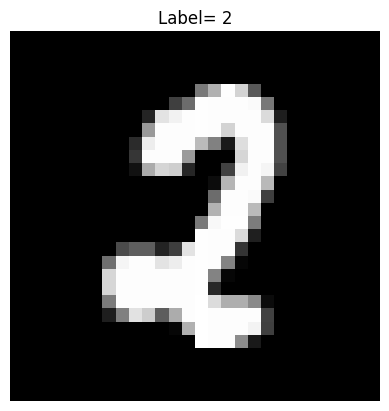

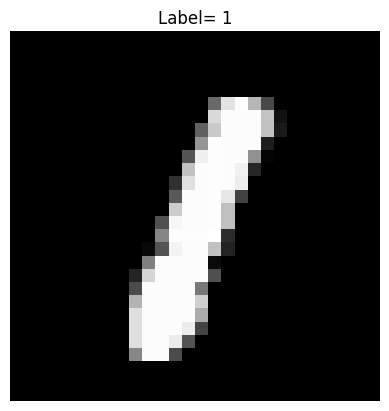

In [37]:
def visualise_samples(dataloader , num_samples):
    dataset = dataloader.dataset
    random_idx = random.sample(range(len(dataset)), num_samples)

    for i in random_idx:
        image,label = dataset[i]
        image = image.view(28,28)
        plt.title(f"Label= {label}")
        plt.imshow(image,"grey")
        plt.axis("off")
        plt.show()

visualise_samples(trainloader,1)
visualise_samples(trainloader,1)
    

## 4) Forward Pass in Numpy [16 Marks]

**4.1) He initialization** [5]

He initialization is used to set the initial weights of neural network layers, especially those with ReLU activations. It helps maintain the variance of activations throughout the network, which improves training stability and convergence.

The formula for He initialization is:
$$
W_{ij} \sim \mathcal{N}\left(0, \frac{2}{\text{in\_dim}}\right)
$$
where $$\text{in\_dim}$$ is the number of input units to the layer. In simple terms, it means the weight matrix is initialised by sampling from a normal distribution with 0 mean and $\frac{2}{\text{in\_dim}}$ variance.

**Write a function, `he_init` function takes two arguments as input:**
- `in_dim`: The number of input units to the layer.
- `out_dim`: The number of output units (neurons) in the layer.

It returns:
- `W`: A weight matrix of shape `(out_dim, in_dim)` initialized using the He initialization method.
- `b`: A bias vector of shape `(out_dim, 1)` initialized to zeros.




In [8]:
def he_init(in_dim , out_dim):
    std = (2/in_dim) ** (1/2)
    W = torch.randn(out_dim,in_dim) * std
    b = torch.randn(out_dim,1)

    return W.numpy(),b.numpy()

**4.2) Weight Initialization** [2]
- Your network should have the following architecture:
    - Input layer: 28x28 (flattened MNIST image)
    - Hidden layer 1: 256 units, ReLU activation
    - Hidden layer 2: 128 units, ReLU activation
    - Output layer: 10 units, softmax activation
- Initialise all the matrices (weights, and biases) using he_init with the correct dimensions.

In [9]:
# Layer 1
W_1,b_1 = he_init(28 * 28,256)
# Layer 2
W_2,b_2 = he_init(256,128)
# Layer 3
W_3,b_3 = he_init(128,10)
print("Weight dim for L1: " , W_1.shape)
print("Weight dim for L2: " , W_2.shape)
print("Weight dim for L3: " , W_3.shape)
print("Bias dim for L1: " , b_1.shape)
print("Bias dim for L2: " , b_2.shape)
print("Bias dim for L3: " , b_3.shape)

Weight dim for L1:  (256, 784)
Weight dim for L2:  (128, 256)
Weight dim for L3:  (10, 128)
Bias dim for L1:  (256, 1)
Bias dim for L2:  (128, 1)
Bias dim for L3:  (10, 1)


**4.3) Activations** [5]
- Write a function for ReLU
- Write a function for Softmax

In [10]:
# Relu
def Relu(z):
    return np.maximum(0,z)

In [11]:
# Softmax
def softmax(z):
    z = np.array(z)
    pred_sum = np.sum(np.exp(z))
    probs = np.exp(z)/pred_sum

    return probs

**4.4) Forward Pass** [5]
- Now that you have your weights initialized, perform a forward pass on an image from the test set of  MNIST.
- Print the output probabilities and the predicted class

In [12]:
Weights = [W_1,W_2,W_3]
Biases = [b_1,b_2,b_3]
test_set = trainloader.dataset
i = random.randint(0,len(test_set) - 1)
image,label = test_set[i]
print(image.shape)
image = image.squeeze().numpy()
image = image.reshape(-1,1)
print(image.shape)
a = image
for i in range(3):
    z = np.dot(Weights[i],a) + Biases[i]
    a = Relu(z)

final_probs = softmax(a)
pred_class = np.argmax(final_probs)

print("True label:", label)
print("Predicted class:", pred_class)


torch.Size([1, 28, 28])
(784, 1)
True label: 3
Predicted class: 3


# 5) Implement the Backward Pass [20 Marks]
### [6 marks Activations + 14 marks Backward Pass]

In this exercise, you will implement **backpropagation** for a lightweight fully connected neural network using only **NumPy**.   The goal is to compute gradients of weights and biases for each layer using the **chain rule** of calculus.  
Note: caches are not required for this implementation

In [13]:
# ---- Activation derivatives (TO BE IMPLEMENTED) ----
def dsigmoid(a):
    return a*(1-a)

def dtanh(a):
    return 1 - a**2

def drelu(z):
    return (z > 0).astype(float)

# ---- Backward Pass (TO BE IMPLEMENTED) ----
def backward(W, b, A, Z, Y, activations):
    """
    Compute gradients for a fully-connected MLP (no caches passed around).
    Inputs:
        W, b  : lists of weights/biases, indexed 1..L
        A, Z  : lists of activations and pre-activations, A[0]=X^T, up to A[L]
        Y     : (m,1) labels
        activations: list of names per layer, e.g. [None, 'tanh', 'sigmoid']
    Returns:
        dW, db: lists of gradients, indexed 1..L
    """

    L = len(W) - 1
    dW = [None] * (L + 1)  # initialize with None at index 0
    db = [None] * (L + 1)
    dZ = A[L] - Y.T

    for i in range(L ,0,-1):
        m = dZ.shape[1]
        dW[i] = (1/m)* np.dot(dZ,A[i-1].T)
        db[i] = ((1/m) * np.sum(dZ , axis= 1 , keepdims=True))
        if i > 1:
            dA_prev = np.dot(W[i].T,dZ)
            if activations[i-1] == 'relu':
                dZ= dA_prev * drelu(Z[i-1])
            elif activations[i-1] == 'tanh':
                dZ = dA_prev * dtanh(A[i-1])
            elif activations[i-1] == 'sigmoid':
                dZ = dA_prev * dsigmoid(A[i-1])


    return dW, db


**Backprop Testing (Just run the code block below without changing anything)**

In [14]:
np.random.seed(0)
m = 4
X = np.random.randn(m,2)
Y = (np.random.rand(m,1) > 0.5).astype(int)

W = [None, np.random.randn(3,2)*0.1, np.random.randn(1,3)*0.1]
b = [None, np.zeros((3,1)), np.zeros((1,1))]
Z = [None,
     np.random.randn(3,m),
     np.random.randn(1,m)]
A = [X.T,
     np.tanh(Z[1]),
     1/(1+np.exp(-Z[2]))]

activations = [None, "tanh", "sigmoid"]

dW, db = backward(W, b, A, Z, Y, activations)

print("dW[1] shape:", None if dW[1] is None else dW[1].shape)
print("db[1] shape:", None if db[1] is None else db[1].shape)
print("dW[2] shape:", None if dW[2] is None else dW[2].shape)
print("db[2] shape:", None if db[2] is None else db[2].shape)

dW[1] shape: (3, 2)
db[1] shape: (3, 1)
dW[2] shape: (1, 3)
db[2] shape: (1, 1)


## 6) Neural Networks In PyTorch [52 Marks]

**6.1) Helper Function** [2]

- Create a function `count_parameters` that takes in a model and returns its parameter count.

In [15]:
def count_parameters(model):
    sum = 0
    for p in model.parameters():
        sum += p.numel() #to get num items in matrix
    return sum

**6.2) Fully-Connected Neural Network (FCNN) for Digit Classification in PyTorch** [5]
- Create a FCNN utilising ReLU activations with more than 200,000 parameters. Print its parameter count.
- Note: You are NOT allowed to use convolutions.

In [16]:
class FCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28,512),
            nn.ReLU(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,10),
         )
        

    def forward(self, x):
        return self.model(x)

model = FCNN()
param_count = count_parameters(model)
print("Parameter Count: ", param_count)

Parameter Count:  567434


**6.3) Hyperparameters** [5]
- Define the criterion, optimizer, and learning rate
- Do NOT change the number of epochs
- In a markdown cell, explain the choice of your criterion (loss function)

In [17]:
EPOCHS = 10
LR = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),lr= LR)

Ans: I went with the CrossEntropyLoss function because it is used for multiclass classification purposes and here the function CrossEntropyLoss() also includes softmax predicitions

**6.4) Training and Evaluation Functions** [15]
- Write a function `train` that takes in the model, dataloader, optimizer, and criterion, and trains the model for one epoch. It should return the average loss and accuracy for that epoch.
- Write a function `evaluate` that takes in the model, dataloader, and criterion, and evaluates the model on the validation or test set. It should return the average loss and accuracy.
- In a markdown cell below, also explain the use of the following functions:
    -  `optimizer.zero_grad()`
    -  `loss.backward()`
    -  `optimizer.step()`

In [18]:
# train function below
def train(model,dataloader,optimizer,criterion):
    model.train()
    losses =[]
    total = 0
    count = 0
    for images,labels in tqdm(dataloader,desc ="Training", leave = False):
        optimizer.zero_grad()

        preds = model(images)
        # print("Prediction For Current Batch:" , preds)
        loss = criterion(preds,labels)
        loss.backward()
        train_pred_class = torch.argmax(preds, dim=1)

        total += labels.size(0)
        count += (train_pred_class == labels).sum().item()
        optimizer.step()
        losses.append(loss.item()) #.item() coverts tenor to numerical value
    avg_loss = np.sum(losses) / len(losses)
    accuracy = count /total * 100
    return avg_loss,accuracy


In [19]:
# evaluate function below
def evaluate(model,dataloader,criterion):
    model.eval()
    total = 0
    losses = []
    count = 0
    with torch.no_grad():
        for images,labels in tqdm(dataloader,desc ="Validating", leave = False):
            preds = model(images)
            # print("Prediction for current batch: ", preds)
            loss = criterion(preds,labels)
            losses.append(loss.item())
            total += labels.size(0)
            test_pred_class = torch.argmax(preds,dim=1)
            count += (test_pred_class == labels).sum().item()
    avg_loss = np.sum(losses) / len(losses)
    accuracy = count /total * 100
    return avg_loss,accuracy


Ans: optimizer.zero_grad() is used to clear all of the past/old gradients and it is needed so that the old ones dont accumulate with the new ones

loss.backward() is used for backwards propogations in which the gradients of loss are recalculated in each of the layers with respect to the model parameters(weights,biases)

optimizer.step() is used to update the model parameters with the use of the recalculated gradients. This is where learning takes place


**6.5) Training Loop** [10]
- Write a loop to train your model for the specified number of epochs.
- For each epoch, print the training loss, training accuracy, validation loss, and validation accuracy.
- Use your `train` and `evaluate` functions to get these values for each epoch.
- Save the model with the best validation accuracy.
- Plot the loss and accuracy curves (for both train and val set).
- Make sure to label the graphs correctly.

Train Loss: 1.2554, Train Acc: 68.25% | Valid Loss: 0.4837, Valid Acc: 85.66%


Train Loss: 0.3644, Train Acc: 89.49% | Valid Loss: 0.3498, Valid Acc: 89.74%


Train Loss: 0.2790, Train Acc: 91.92% | Valid Loss: 0.2782, Valid Acc: 92.17%


Train Loss: 0.2319, Train Acc: 93.27% | Valid Loss: 0.2482, Valid Acc: 92.94%


Train Loss: 0.1971, Train Acc: 94.36% | Valid Loss: 0.2339, Valid Acc: 92.86%


Train Loss: 0.1686, Train Acc: 95.14% | Valid Loss: 0.1863, Valid Acc: 94.75%


Train Loss: 0.1470, Train Acc: 95.69% | Valid Loss: 0.1780, Valid Acc: 94.93%


Train Loss: 0.1294, Train Acc: 96.24% | Valid Loss: 0.1563, Valid Acc: 95.40%


Train Loss: 0.1151, Train Acc: 96.69% | Valid Loss: 0.1530, Valid Acc: 95.49%


Train Loss: 0.1033, Train Acc: 96.96% | Valid Loss: 0.1595, Valid Acc: 95.19%


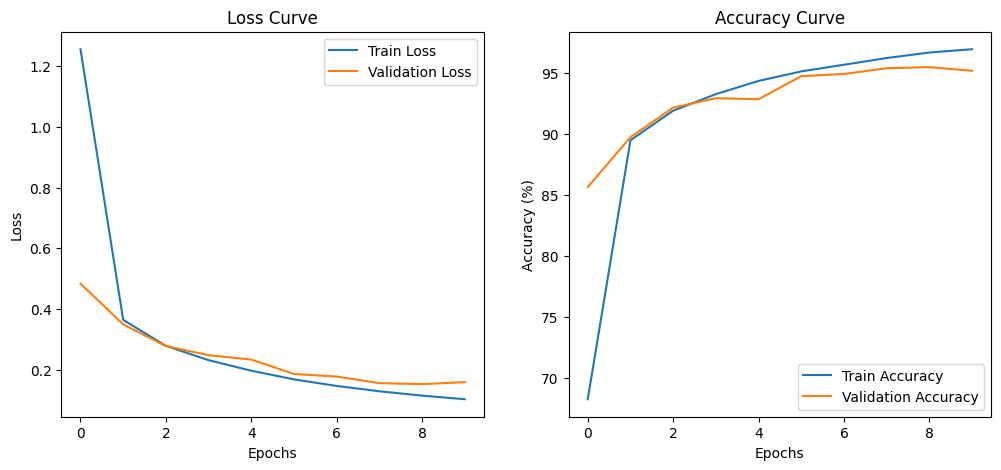

In [20]:
train_loss = 0
train_acc = 0
valid_loss = 0
valid_acc = 0
best_acc = 0
best_model = FCNN()
train_losses = []
valid_losses = []
train_accs = []
valid_accs = []
for epoch in range(EPOCHS):
    train_loss,train_acc = train(model,trainloader,optimizer,criterion)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    valid_loss,valid_acc = evaluate(model,validloader,criterion)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)
    if(valid_acc > best_acc):
        best_acc = valid_acc
        best_model.load_state_dict(model.state_dict())
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
        f"Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.2f}%")
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(valid_accs, label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.show()

**6.6) Evaluation** [10]
- Load the model with the best validation accuracy.
- Evaluate this model on the test set and report the following:
    - Accuracy **(should be higher than 95%)**
    - F1 (macro) **(should be higher than 95%)**
    - Recall (macro) **(should be higher than 95%)**
- Print the classification report.
- Visualise the confusion matrix.
- Plot the ROC curve.
- Write a function `visualise_incorrect` that visualises the incorrectly labelled samples with their true and predicted labels.

In [21]:
# Load the best model below
final_model = FCNN()
final_model.load_state_dict(best_model.state_dict())
model.eval()
final_preds = []
final_labels = []
with torch.no_grad():
    for images,labels in testloader:
        test_preds = model(images)
        test_prediction = torch.argmax(test_preds,dim=1)
        final_preds.extend(test_prediction.numpy())
        final_labels.extend(labels.numpy())

In [22]:
# Show required evaluation metrics below
acc = accuracy_score(final_labels,final_preds)
f1 = f1_score(final_labels, final_preds, average='macro')
recall = recall_score(final_labels, final_preds, average='macro')

print(f"Accuracy: {acc:.3f}")
print(f"F1 Score (macro): {f1:.3f}")
print(f"Recall (macro): {recall:.3f}")
print(classification_report(final_labels, final_preds))


Accuracy: 0.958
F1 Score (macro): 0.958
Recall (macro): 0.958
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       980
           1       0.98      0.98      0.98      1135
           2       0.98      0.95      0.96      1032
           3       0.96      0.95      0.96      1010
           4       0.96      0.95      0.96       982
           5       0.95      0.96      0.96       892
           6       0.98      0.95      0.96       958
           7       0.98      0.92      0.95      1028
           8       0.89      0.98      0.94       974
           9       0.91      0.96      0.93      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



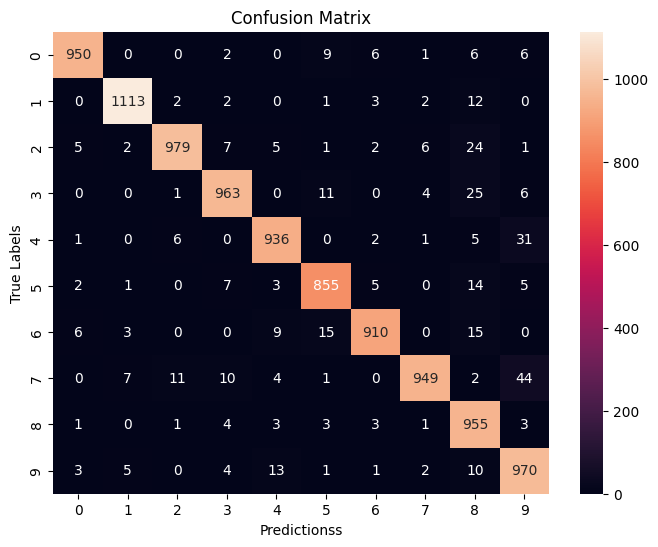

In [23]:
# Plot confusion matrix below
cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predictionss")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Plot ROC curve below



In [25]:
# Write visualise function below and make sure to visalize some atleast two samples
def visualise_incorrect(model, dataloader, n=5):
    model.eval()
    incorrect_images = []
    true_labels = []
    pred_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            preds = model(images)
            pred_classes = torch.argmax(preds, dim=1)
            mask = (pred_classes != labels)
            if mask.any():
                incorrect_images.append(images[mask])
                true_labels.append(labels[mask])
                pred_labels.append(pred_classes[mask])
                
    final_incorrect_images = torch.cat(incorrect_images) #to combine the tensorsn that have incorret imgs per batch
    final_true_labels = torch.cat(true_labels)
    final_pred_labels = torch.cat(pred_labels)

    for i in range(min(n, len(final_incorrect_images))):
        plt.imshow(final_incorrect_images[i].squeeze(), cmap='gray')
        plt.title(f"True: {final_true_labels[i].item()}, Pred: {final_pred_labels[i].item()}")
        plt.axis('off')
        plt.show()


**6.7) Out-of-distribution (OOD) Evaluation** [5]
- Write any digit on a piece of paper and take a photo of it.
- Load the photo and apply any processing necessary to get the image ready to be passed into the FCNN.
- Visualise the image.
- Run inference on the image and print all the output probabilities and its predicted class.
- Comment on whether the model is able to correctly predict the digit? Why or why not? 

0.41665


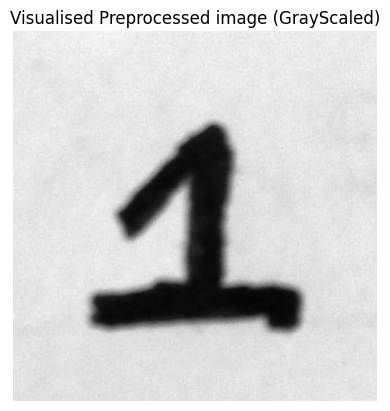

Class Probabilities: 
Class = 0 and its respective probability is 0.12545
Class = 1 and its respective probability is 0.06667
Class = 2 and its respective probability is 0.16596
Class = 3 and its respective probability is 0.28848
Class = 4 and its respective probability is 0.00648
Class = 5 and its respective probability is 0.09419
Class = 6 and its respective probability is 0.01197
Class = 7 and its respective probability is 0.13682
Class = 8 and its respective probability is 0.05196
Class = 9 and its respective probability is 0.05202

Predicted Class: 3 with it probability = 0.2885


In [ ]:
image_transform = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])
image = Image.open("C:\\Users\\Muhammad Bilal\\Downloads\\OOD Test image .jpg").convert("L")
temp_img = transforms.ToTensor()(image)
mean = float(temp_img.mean().item())
print(f"{mean:.5f}")
disp_img = transforms.ToTensor()(image).squeeze().numpy()
image = image_transform(image)
plt.imshow(disp_img, cmap='gray')
plt.title("Visualised Preprocessed image (GrayScaled)")
plt.axis('off')
plt.show()

model.eval()

with torch.no_grad():
    model_pred = model(image.unsqueeze(0))
    pred_probs = torch.softmax(model_pred,dim=1).numpy().squeeze()
    final_pred = int(np.argmax(pred_probs))

print("Class Probabilities: ")
for c , prob in enumerate(pred_probs):
    print(f"Class = {c} and its respective probability is {prob:.5f}")
print()
print(f"Predicted Class: {final_pred} with it probability = {pred_probs[final_pred]:.4f}")

The predicted class was wrong ,that since the image was captured using a phone and although resized to 28 x 28 and normalised with MNIST mean/std it still lacked the attributes of a MNIST image. For example, since most the pixels in the MNIST image are black the mean pixel value is low while it is the inverse in our image with the mean being high(0.41665).Other factors like brightness,contrast or underlying distinct patterns could exist due to which the model failed to generalise an out of the distribution image